# 06 — Scenarios & Running Models

The FloPy-style loop: **modify → run → compare**, scripted end to end.

- `create_scenario()` — copy a model and apply declarative changes
- `run_model()` — drive the real IWFM executables
  (PreProcessor → Simulation → Budget → ZBudget)
- `compare_models()` / `head_difference()` / `budget_difference()` —
  quantify what changed

**Requires: Windows** + the sample model with its executables in
`Bin/` (they ship inside `sample_model.zip`). The scenario run itself
takes ~1–2 minutes.

In [1]:
import json
import os
import sys
import tempfile
from pathlib import Path

assert sys.platform == "win32", "running IWFM executables requires Windows"


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("sample model not found — see notebook 01")


SAMPLE_MODEL = find_sample_model()
assert (SAMPLE_MODEL / "Bin").is_dir(), \
    "IWFM executables not found in <model>/Bin (or set IWFM_BIN_DIR)"

WORK = Path(tempfile.mkdtemp(prefix="iwfm_nb06_"))
print("scenario workspace:", WORK)

scenario workspace: C:\Projects\iwfm-io\notebooks\tmp\iwfm_nb06_b1cn_o9s


## 1. Create a scenario

`create_scenario(base, out, changes=[...])` copies the model folder and
applies **change factories**:

- `set_keyed_value(file, key, value)` — edit a `VALUE / KEYWORD` line
- `replace_text(file, old, new)` — targeted text substitution

Here: shorten the simulation to two years and cut ET by 10 % — a quick
dry-climate what-if.

In [2]:
from iwfm_io import create_scenario, set_keyed_value

scenario = create_scenario(
    SAMPLE_MODEL,
    WORK / "dry_two_year",
    changes=[
        set_keyed_value("Simulation/Simulation_MAIN.IN",
                        "EDT", "09/30/1992_24:00"),
    ],
)
print("scenario created:", scenario)

scenario created: C:\Projects\iwfm-io\notebooks\tmp\iwfm_nb06_b1cn_o9s\dry_two_year


### Fast worker copies: `link_unchanged=True`

For many parallel copies of a large model (PEST workers!),
`create_scenario(..., link_unchanged=True)` **hardlinks** unchanged
files instead of copying — near-instant, ~zero marginal disk. Changed
files stay real copies (writers replace files atomically, so a link is
never edited in place), and output-like suffixes (`.out`, `.hdf`,
`.dss`, …) are always real-copied because the executables rewrite them.
Same-volume only; falls back to copying with a warning otherwise.

In [3]:
import time

t0 = time.perf_counter()
linked = create_scenario(
    SAMPLE_MODEL, WORK / "linked_copy",
    changes=[set_keyed_value("Simulation/Simulation_MAIN.IN",
                             "EDT", "09/30/1992_24:00")],
    link_unchanged=True,
)
print(f"hardlinked replica in {time.perf_counter() - t0:.2f} s")

# the changed file is a real copy; an unchanged input is a hardlink
changed = linked / "Simulation" / "Simulation_MAIN.IN"
unchanged = linked / "Preprocessor" / "NodeXY.dat"
print("Simulation_MAIN.IN links:", os.stat(changed).st_nlink)
print("NodeXY.dat links:        ", os.stat(unchanged).st_nlink)

hardlinked replica in 0.06 s
Simulation_MAIN.IN links: 1
NodeXY.dat links:         3


## 2. Run the IWFM toolchain

`run_model(dir, steps=...)` resolves the executables from `<model>/Bin`
(or `IWFM_BIN_DIR`), runs each as `exe INPUT_FILE` with the input file's
folder as working directory — exactly like DWR's `.bat` files — and
fails fast on a nonzero exit or FATAL/ERROR in the output/message files.

In [4]:
from iwfm_io import run_model

results = run_model(
    scenario,
    steps=("preprocessor", "simulation", "budget", "zbudget"),
    timeout=3600,
)
for step, result in results.items():
    print(f"{step:14s} {result}")

Running preprocessor (PreProcessor_x64.exe PreProcessor_MAIN.IN) ...

 OK (0.2s)


Running simulation (Simulation_x64.exe Simulation_MAIN.IN) ...

 OK (27.4s)
Running budget (Budget_x64.exe Budget.in) ...

 OK (0.5s)
Running zbudget (ZBudget_x64.exe ZBudget.in) ...

 OK (0.9s)
preprocessor   <RunResult preprocessor: OK in 0.2s>
simulation     <RunResult simulation: OK in 27.4s>
budget         <RunResult budget: OK in 0.5s>
zbudget        <RunResult zbudget: OK in 0.9s>


## 3. Open the results

A fresh executable run writes **text** outputs (plus budget HDFs) —
`open_model` falls back to `GWHeadAll.out` for heads automatically.

In [5]:
from iwfm_io import open_model

run = open_model(scenario)
print(json.dumps(run.describe()["simulation"], indent=2))
heads = run.heads_df(layer=1)
print(f"scenario heads: {heads.shape[0]} timesteps x {heads.shape[1]} nodes")

{
  "begins": "09/30/1990_24:00",
  "ends": "09/30/1992_24:00",
  "timestep": "1DAY"
}


scenario heads: 732 timesteps x 441 nodes


## 4. Compare against the baseline

Three levels, from coarse to numeric:

1. `diff_model_files()` — which input files differ?
2. `compare_models()` — one-call report (files + grid + heads + budgets)
3. `head_difference()` / `budget_difference()` — aligned B − A frames

In [6]:
from iwfm_io import compare_models, diff_model_files

d = diff_model_files(SAMPLE_MODEL, scenario,
                     subdirs=["Preprocessor", "Simulation"])
print(f"compared {d['n_compared']} files; changed: {d['changed']}")

compared 57 files; changed: ['Preprocessor/PreprocessorMessages.out', 'Simulation/SimulationMessages.out', 'Simulation/Simulation_MAIN.IN']


In [7]:
report = compare_models(SAMPLE_MODEL, scenario,
                        file_subdirs=["Preprocessor", "Simulation"])
print("changed files:", report["files"]["changed"])
print("head statistics over the common period (layer 1):")
print(json.dumps(report["heads"]["layer_1"], indent=2))

changed files: ['Preprocessor/PreprocessorMessages.out', 'Simulation/SimulationMessages.out', 'Simulation/Simulation_MAIN.IN']
head statistics over the common period (layer 1):
{
  "rmse": 0.0,
  "mean_diff": 0.0,
  "max_abs_diff": 0.0,
  "max_abs_diff_node": "node_1",
  "max_abs_diff_date": "1990-10-01"
}


In [8]:
from iwfm_io import budget_difference, head_difference

dh = head_difference(SAMPLE_MODEL, scenario, layer=1)
print(f"head difference frame: {dh.shape} "
      f"(max |diff| = {abs(dh.values).max():.3f} ft)")

dbud = budget_difference(SAMPLE_MODEL, scenario, "GW",
                         location="ENTIRE MODEL AREA", interval="1YEAR")
dbud.head(3)

head difference frame: (732, 441) (max |diff| = 0.000 ft)


,Percolation,Beginning Storage (+),Ending Storage (-),Deep Percolation (+),Gain from Stream (+),Recharge (+),Gain from Lake (+),Boundary Inflow (+),Subsidence (+),Subsurface Irrigation (+),Tile Drain Outflow (-),Pumping (-),GW Return Flow (-),Outflow to Root Zone (-),Net Subsurface Inflow (+),Discrepancy (=),Cumulative Subsidence
datetime,,,,,,,,,,,,,,,,,
1990-12-31,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0000,0.000000
1991-12-31,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0000,0.000000
1992-12-31,-1.727686e+09,0.0,-4.715120e+09,-6.392457e+08,-3.415054e+09,0.0,-7.929052e+07,-6.462085e+08,-405364.193832,0.0,-1.337400e+07,-5.170994e+07,0.0,0.0,0.0,-48.7177,-405364.193832


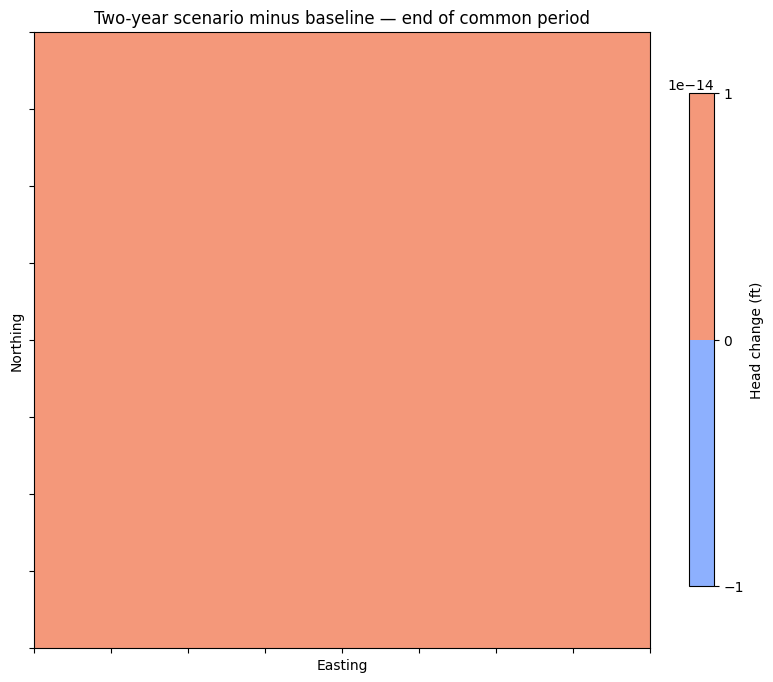

In [9]:
# Map the end-of-run head difference (scenario − baseline)
import matplotlib.pyplot as plt

from iwfm_io.plots import plot_contour_map

baseline = open_model(SAMPLE_MODEL)
fig, ax, cs, cb = plot_contour_map(
    baseline, dh.iloc[-1].values, cmap="coolwarm",
    label="Head change (ft)",
    title="Two-year scenario minus baseline — end of common period")
plt.show()

## 5. Scenario budgets join the multi-run frame

The scenario's Results folder drops straight into `collect_budgets`
(notebook 03) for run-vs-run budget analysis.

In [10]:
from iwfm_io import collect_budgets

df = collect_budgets(
    runs={"baseline": SAMPLE_MODEL / "Results",
          "dry_2yr": scenario / "Results"},
    budget_files={"GW": "GW.hdf"},
)
pumping = (df[df["component"].str.contains("Pumping")]
           .groupby(["run", "location"], observed=True)["value"].sum()
           .unstack("run"))
pumping

run,baseline,dry_2yr
location,,
ENTIRE MODEL AREA,1.112480e+11,2.236037e+10
Region1 (SR1),1.103116e+11,2.217303e+10
Region2 (SR2),9.364254e+08,1.873437e+08


In [11]:
import shutil

shutil.rmtree(WORK, ignore_errors=True)
print("workspace removed")

workspace removed


## Recap — the scenario loop

```python
scen = create_scenario(base, out, changes=[set_keyed_value(...), ...],
                       link_unchanged=True)   # fast worker copies
run_model(scen)                               # PP -> Sim -> Budget -> ZBudget
report = compare_models(base, scen)           # what changed?
```

Runtime scales with the model: sample ≈ 40 s for the simulation,
C2VSimFG ≈ 8 h. Notebook 09 builds on exactly this loop for PEST
calibration (the `apply → run → extract` forward run).